# Histogram delta compression — wire bytes and throughput

Reads the output of `scripts/benchmarking/histogram_delta/run.sh` and draws the two figures:

1. **Bytes on the wire** per payload representation (rate-limited run — every variant ingests the same
   tuples, so a difference in bytes is a difference in representation).
2. **Ingest throughput** per representation (unthrottled Memory-source run, median of repetitions).

The two come from separate runs by necessity: equalising ingest is what makes the byte counts
comparable, and *not* equalising it is what makes the throughput meaningful.

Figures are drawn without a title or subtitle — they sit under a paper caption. What stays on the
canvas is what a caption cannot replace: axis labels, category labels and per-bar values.

In [1]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### The two flat CSVs run.sh writes into the output root.
BYTES_CSV = "results_histogram_delta_bytes.csv"
THROUGHPUT_CSV = "results_histogram_delta_throughput.csv"

### Point RESULTS_DIR at the run you want to plot (the OUT_ROOT that run.sh printed), or leave it
### unset to auto-pick the most recent benchmark_run_* under the notebook, the repo root or /tmp.
### A candidate counts only if it holds the bytes CSV, so a half-written run is never picked.
def _autopick_run():
    here = Path.cwd()
    if (here / BYTES_CSV).exists():
        return here
    # plots/ -> histogram_delta/ -> benchmarking/ -> scripts/ -> repo root
    repo_root = (here / ".." / ".." / ".." / "..").resolve()
    candidates = []
    for base in (here, repo_root, Path("/tmp"), Path.home()):
        # benchmark_run_* is run.sh's default; bench-* is what we use on the remote, where output
        # must live outside the synced tree or rsync deletes it mid-run.
        candidates += glob.glob(str(base / "benchmark_run_*"))
        candidates += glob.glob(str(base / "bench-*"))
    candidates = [Path(c) for c in candidates if (Path(c) / BYTES_CSV).exists()]
    if not candidates:
        raise FileNotFoundError(
            f"No run with {BYTES_CSV} found. Produce one with\n"
            "    bash scripts/benchmarking/histogram_delta/run.sh\n"
            "or set RESULTS_DIR explicitly.")
    return max(candidates, key=lambda d: d.stat().st_mtime)


RESULTS_DIR = Path(os.environ["RESULTS_DIR"]) if os.environ.get("RESULTS_DIR") else _autopick_run()
OUT_DIR = Path(os.environ.get("FIGURE_DIR", RESULTS_DIR / "figures"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("results:", RESULTS_DIR.resolve())
print("figures:", OUT_DIR.resolve())

results: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots
figures: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures


## Styling

Colours come from seaborn's `colorblind` palette, the same source as the other notebooks under
`scripts/benchmarking/`. The assignment is deliberate: hue family = plan shape (blue = full synopsis,
orange = delta), and the lighter tone within each family = the zstd-compressed variant. That keeps
"which representation" and "is it compressed" readable as two separate visual questions.

Colour is never the only encoding: every bar carries its category as a tick label and its value as a
direct label, so the figures survive greyscale printing and any colour-vision deficiency.

Figure geometry follows the shared paper convention (`PAPER_RC`, `COL_W`/`FULL_W`, TrueType-embedded
PDF), so the output drops into a two-column layout at roughly 1:1.

In [2]:
### Shared "paper" look, kept in sync with the other benchmarking notebooks.
sns.set_theme(style="whitegrid", context="paper")

### Sized for a VLDB/SIGMOD/ICDE two-column camera-ready: figures go in at ~1:1, so the sizes here are
### the sizes on the page (body text is 9-10pt).
PAPER_RC = {
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "pdf.fonttype": 42,  # TrueType, not Type-3: ACM/IEEE preflight rejects Type-3
    "ps.fonttype": 42,
}

### Column widths in inches: single column and full width of a two-column layout.
COL_W, FULL_W = 3.3, 7.0

VARIANT_ORDER = ["prometheus", "split", "split_zstd", "delta", "delta_zstd"]
VARIANT_LABEL = {
    "prometheus": "Central",
    "split": "Full",
    "split_zstd": "Zstd",
    "delta": "Delta",
    "delta_zstd": "Delta + Zstd",
}
BASELINE = "split"  # every comparison is against the uncompressed synopsis

### Font sizes for the axis furniture, set above PAPER_RC's defaults: these figures are placed as
### narrow subfigures and scaled down further, so the axis text has to start bigger to survive it.
LABEL_FS = 11   # y-axis label
TICK_FS = 9     # x category labels and y tick labels

### Bar width as a fraction of the category slot. Narrow bars with generous gaps read as
### discrete categories; wide ones start to look like a histogram of a continuous variable,
### which these are not.
BAR_WIDTH = 0.45

### No x-axis label: the tick labels already name every category, so an axis title would only repeat
### them in a figure this small.

### Prepended to every saved figure, so the files stay identifiable once they are sitting
### in the paper's figure directory next to everyone else's.
FIGURE_PREFIX = "histogram_compression_"

### Colours from seaborn's colorblind palette, as everywhere else in scripts/benchmarking. The
### assignment is deliberate: hue family = plan shape (blue = full synopsis, orange = delta), lighter
### within the family = the zstd'd variant. So "which representation" and "is it compressed" stay
### readable as two separate visual questions.
_palette = sns.color_palette("colorblind")
VARIANT_COLOR = {
    ### Grey, not a family colour: prometheus is the reference ARCHITECTURE (raw stream, bucketed at
    ### the sink), not another payload encoding of the same synopsis, so it should not read as a
    ### member of either the blue or the orange family.
    "prometheus": _palette[7],  # grey
    "split": _palette[0],       # blue
    "split_zstd": _palette[9],  # light blue
    "delta": _palette[3],       # vermilion
    "delta_zstd": _palette[1],  # orange
}


def style_axis(ax, grid_axis="y"):
    """The per-axis finishing every figure in these notebooks shares."""
    ax.grid(True, axis=grid_axis, linestyle=":", linewidth=0.4, alpha=0.6)
    ax.grid(False, axis="x")  # vertical gridlines say nothing about nominal categories
    ax.tick_params(length=2, width=0.6)
    sns.despine(ax=ax)


def ordered(variants):
    present = set(variants)
    return [v for v in VARIANT_ORDER if v in present]


def bars(ax, variants, values, notes, ylabel, show_xticklabels=True, reference=None):
    """One panel: vertical bars, linear axis, a direct label per bar.

    Linear on purpose: bar height must stay proportional to the value it encodes, so a log axis is not
    an option even though the values span a wide range.

    `reference` is (value, label): the Central architecture, drawn as a dashed horizontal line rather
    than a fifth bar. It is not another payload encoding of the same synopsis, so it reads better as
    the level the WEAVE bars are measured against than as a peer of theirs.
    """
    xpos = range(len(variants))
    ax.bar(xpos, values, color=[VARIANT_COLOR[v] for v in variants], width=BAR_WIDTH, zorder=3)
    for x, v, note in zip(xpos, values, notes):
        ax.annotate(note, (x, v), fontsize=6, ha="center", va="bottom",
                    xytext=(0, 2), textcoords="offset points", linespacing=1.25)
    ax.set_xticks(list(xpos))
    ### Shared x across the stacked panels: only the bottom one carries the category names.
    ax.set_xticklabels([VARIANT_LABEL[v] for v in variants] if show_xticklabels else [],
                       fontsize=TICK_FS)
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ### clip_on is True here (seaborn's theme), which makes savefig's tight bbox stop at the axes
    ### edge — at LABEL_FS the label is taller than the axes, so its tail was being cropped off.
    ax.yaxis.label.set_clip_on(False)
    top = max(values + [reference[0]]) if reference else max(values)
    if reference:
        ax.axhline(reference[0], color=VARIANT_COLOR["prometheus"], linestyle="--", linewidth=1.0, zorder=2)
        ax.annotate(reference[1], (0.99, reference[0]), xycoords=("axes fraction", "data"),
                    fontsize=6, ha="right", va="bottom", xytext=(0, 2), textcoords="offset points",
                    color=VARIANT_COLOR["prometheus"],
                    ### The line can run behind a bar (throughput figure), so the label carries its own
                    ### background rather than being read on top of one.
                    bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0, "alpha": 0.85})
    ax.set_ylim(0, top * 1.24)  # headroom for the value labels
    style_axis(ax)
    ax.tick_params(labelsize=TICK_FS)


def finish(fig, ax, name):
    """Tilt the category labels, then write the figure as PDF (for LaTeX) and PNG (for looking at).

    Each figure is COL_W wide and saved separately, so they can be placed as two subfigures of one
    column rather than being welded into a single image.
    """
    for label in ax.get_xticklabels():
        ### 30, not 20: at TICK_FS the labels are wide enough that a shallower tilt runs the
        ### two-line labels into their neighbours. The two lines stay centred on each other.
        label.set_rotation(30)
        label.set_ha("right")
        label.set_rotation_mode("anchor")
        label.set_multialignment("center")
    fig.tight_layout()
    for ext, kw in (("pdf", {}), ("png", {"dpi": 200})):
        out = OUT_DIR / f"{FIGURE_PREFIX}{name}.{ext}"
        ### pad_inches is a hair above 0 (0.72pt, invisible) rather than exactly 0: the y-label is
        ### taller than the axes at LABEL_FS, so its ink lands exactly on the crop boundary and the
        ### last glyph came out shaved.
        fig.savefig(out, bbox_inches="tight", pad_inches=0.01, **kw)
        print("wrote", out)


## Figure 1 — bytes on the wire

`total_bytes` is the root container's eth0 RX over the run, i.e. everything that actually crossed the
network to reach the store owner.

In [3]:
wire = pd.read_csv(RESULTS_DIR / BYTES_CSV)
### One topology per figure; default runs use 1/1. Take the first if several were swept.
wire = wire[wire["topology"] == sorted(wire["topology"].unique())[0]]
wire = wire[wire["variant"].isin(VARIANT_ORDER)]
bytes_variants = ordered(wire["variant"])
mb = {v: wire.loc[wire["variant"] == v, "total_bytes"].iloc[0] / 1e6 for v in bytes_variants}
base = mb.get(BASELINE)  # None if VARIANTS excluded the baseline; the ratio line is then omitted

### Value only. The ratios against the baseline live in the printed table below, not on the canvas --
### the bar heights already show the relationship, and the second line crowded the short bars.
bytes_notes = [f"{mb[v]:,.1f} MB" for v in bytes_variants]

print(pd.DataFrame({"variant": bytes_variants,
                    "MB": [round(mb[v], 2) for v in bytes_variants],
                    "vs split": [round(base / mb[v], 2) if base else None for v in bytes_variants]}
                   ).to_string(index=False))

   variant     MB  vs split
prometheus 116.45      0.48
     split  55.34      1.00
split_zstd  28.06      1.97
     delta  13.13      4.21
delta_zstd   6.79      8.15


## Figure 2 — ingest throughput

`mean_tps` is the engine's own throughput listener, averaged over the active span (first to last
non-zero sample, interior zeros kept so stalls count). Grouped by local query id and taken over the
busiest stream, so a delta run's GEN ingest rate is not averaged with its RESOLVER's
one-blob-per-window rate.

Median across repetitions rather than mean: one run that hit a slow compile is an outlier and should
not drag the reported figure. The observed spread is printed alongside.

In [4]:
### ONLY=bytes leaves this file unwritten. Degrade to a bytes-only figure rather than failing: the
### combined cell below checks `tps_variants`.
_tp_path = RESULTS_DIR / THROUGHPUT_CSV
tps_variants, mtps, agg, base_tps, tps_notes = [], {}, None, None, []

if not _tp_path.exists():
    print(f"No {THROUGHPUT_CSV} under {RESULTS_DIR} -- the figure will show bytes only.\n"
          "Produce it with:  ONLY=throughput bash scripts/benchmarking/histogram_delta/run.sh")
else:
    tp = pd.read_csv(_tp_path)
    tp = tp[tp["variant"].isin(VARIANT_ORDER)]
    ### run.sh merges the repetitions into this one file, tagging each with its `run`.
    print(f"{tp['run'].nunique()} repetition(s):", sorted(tp["run"].unique()))

    ### Median across repetitions, not mean: one run that hit a slow compile is an outlier and should
    ### not drag the reported figure. min/max are kept for the spread report.
    agg = tp.groupby("variant")["mean_tps"].agg(["median", "min", "max"]) / 1e6
    tps_variants = ordered(agg.index)
    mtps = {v: agg.loc[v, "median"] for v in tps_variants}
    base_tps = mtps.get(BASELINE)
    tps_notes = [f"{mtps[v]:.2f} M/s" for v in tps_variants]

    report = agg.loc[tps_variants].copy()
    report["spread %"] = ((report["max"] - report["min"]) / report["max"] * 100).round(1)
    if base_tps:
        report["vs split %"] = ((report["median"] / base_tps - 1) * 100).round(0)
    print(report.round(3).to_string())

5 repetition(s): ['run1', 'run2', 'run3', 'run4', 'run5']
            median    min    max  spread %  vs split %
variant                                               
prometheus   1.981  1.902  3.578      46.8       -60.0
split        4.924  1.807  5.023      64.0         0.0
split_zstd   2.171  1.895  2.184      13.2       -56.0
delta        5.189  5.162  5.217       1.0         5.0
delta_zstd   4.528  3.771  4.612      18.2        -8.0


## Figure 1 — bytes on the wire

One column wide, saved on its own.

wrote /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures/histogram_compression_wire_bytes.pdf
wrote /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures/histogram_compression_wire_bytes.png


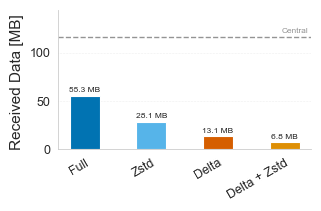

In [5]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 2.2))
    ### Central is the reference architecture (raw sample stream, bucketed at the sink), so it is the
    ### dashed line the WEAVE encodings are read against -- not a fifth bar next to them.
    weave = [v for v in bytes_variants if v != "prometheus"]
    bars(ax, weave, [mb[v] for v in weave],
         [n for v, n in zip(bytes_variants, bytes_notes) if v != "prometheus"],
         "Received Data [MB] ",
         reference=(mb["prometheus"], f"Central"))
    finish(fig, ax, "wire_bytes")

## Figure 2 — ingest throughput

Same width and category order as Figure 1, so the two line up when placed as subfigures.

wrote /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures/histogram_compression_throughput.pdf
wrote /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures/histogram_compression_throughput.png


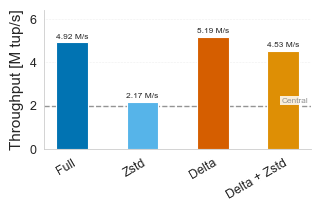

In [6]:
if not tps_variants:
    print("no throughput data -- skipping this figure")
else:
    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(COL_W, 2.2))
        weave = [v for v in tps_variants if v != "prometheus"]
        bars(ax, weave, [mtps[v] for v in weave],
             [n for v, n in zip(tps_variants, tps_notes) if v != "prometheus"],
             "Throughput [M tup/s]",
             reference=(mtps["prometheus"], f"Central"))
        finish(fig, ax, "throughput")

## Table view

Every number behind both figures, so nothing is reachable only by reading a bar height.

In [7]:
table = (wire[["variant", "total_bytes"]]
         .assign(MB=lambda d: (d["total_bytes"] / 1e6).round(2))
         .drop(columns="total_bytes"))
### Throughput columns only when that half ran (ONLY=bytes leaves `agg` unset).
if agg is not None:
    table = table.merge(agg["median"].rename("MTup_s").round(2), on="variant")
if base:
    table["bytes_vs_split"] = (base / table["variant"].map(mb)).round(2)
if base_tps:
    table["tps_vs_split_%"] = ((table["variant"].map(mtps) / base_tps - 1) * 100).round(0)
table = table.set_index("variant").loc[bytes_variants]
display(table)
table.to_csv(OUT_DIR / "figures_table.csv")
print("wrote", OUT_DIR / "figures_table.csv")

,MB,MTup_s,bytes_vs_split,tps_vs_split_%
variant,,,,
prometheus,116.45,1.98,0.48,-60.0
split,55.34,4.92,1.00,0.0
split_zstd,28.06,2.17,1.97,-56.0
delta,13.13,5.19,4.21,5.0
delta_zstd,6.79,4.53,8.15,-8.0


wrote /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/histogram_delta/plots/figures/figures_table.csv
